In [1]:
# Numerical operations
import numpy as np

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.cluster import KMeans

# Train/test split
from sklearn.model_selection import train_test_split

# Clustering evaluation
from sklearn.metrics import silhouette_score

In [4]:
# Create a simple customer dataset

data = {
    "Annual_Income": [
        15, 16, 17, 18, 20,
        40, 42, 45, 47, 50,
        80, 82, 85, 88, 90
    ],
    
    "Spending_Score": [
        80, 85, 78, 82, 88,
        40, 45, 35, 42, 38,
        20, 25, 18, 22, 28
    ]
}



In [8]:
data.keys()

dict_keys(['Annual_Income', 'Spending_Score'])

In [11]:
data.values()

dict_values([[15, 16, 17, 18, 20, 40, 42, 45, 47, 50, 80, 82, 85, 88, 90], [80, 85, 78, 82, 88, 40, 45, 35, 42, 38, 20, 25, 18, 22, 28]])

In [7]:
data['Annual_Income']

[15, 16, 17, 18, 20, 40, 42, 45, 47, 50, 80, 82, 85, 88, 90]

In [6]:
data['Spending_Score']


[80, 85, 78, 82, 88, 40, 45, 35, 42, 38, 20, 25, 18, 22, 28]

## Let' Create Pandas DataFrame

In [16]:
df = pd.DataFrame(data)

In [17]:
df.head()

,Annual_Income,Spending_Score
0,15,80
1,16,85
2,17,78
3,18,82
4,20,88


In [18]:
# Basic statistical information

df.describe()

,Annual_Income,Spending_Score
count,15.000000,15.000000
mean,49.000000,48.400000
std,28.995073,26.340626
min,15.000000,18.000000
25%,19.000000,26.500000
50%,45.000000,40.000000
75%,81.000000,79.000000
max,90.000000,88.000000


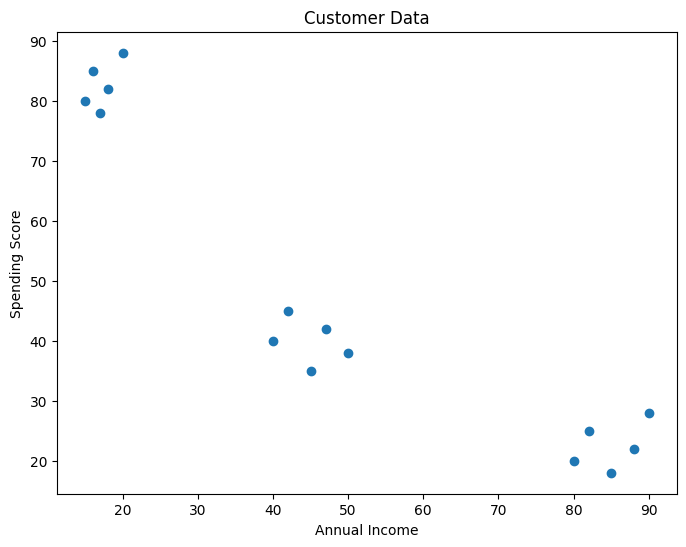

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Data")

plt.show()

# Why not to use LG or other algorithm here?

In [21]:
# Select the features we want K-Means to use

X = df[["Annual_Income","Spending_Score"]]

X.head()

,Annual_Income,Spending_Score
0,15,80
1,16,85
2,17,78
3,18,82
4,20,88


## Creating Training and Testing Data

In [22]:
# Train/test split
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test = train_test_split(
    X,
    test_size=0.30,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 10
Testing samples: 5


In [24]:
X_train.ndim

2

In [25]:
X_train

,Annual_Income,Spending_Score
8,47,42
2,17,78
1,16,85
14,90,28
4,20,88
7,45,35
10,80,20
12,85,18
3,18,82
6,42,45


In [26]:
X_test.ndim

2

In [27]:
X_test

,Annual_Income,Spending_Score
9,50,38
11,82,25
0,15,80
13,88,22
5,40,40


In [42]:
X_train['Annual_Income'].min(), X_train['Annual_Income'].max()

(np.int64(16), np.int64(90))

In [43]:
X_train['Annual_Income'].argmin()

np.int64(2)

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

In [32]:
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[ 0.03573252, -0.37758922],
       [-1.03624312,  0.96827335],
       [-1.07197564,  1.22996885],
       [ 1.57223093, -0.90098022],
       [-0.92904555,  1.34212407],
       [-0.03573252, -0.63928472],
       [ 1.21490572, -1.2000608 ],
       [ 1.39356833, -1.27483094],
       [-1.00051059,  1.11781364],
       [-0.14293008, -0.26543401]])

In [33]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled

array([[ 0.14293008, -0.52712951],
       [ 1.28637076, -1.01313544],
       [-1.10770816,  1.0430435 ],
       [ 1.50076589, -1.12529065],
       [-0.21439513, -0.45235937]])

## Selecting Algorithm

In [28]:
# Machine learning
from sklearn.cluster import KMeans

In [47]:
model = KMeans()

In [48]:
# Train K-Means using the training data

model.fit(X_train)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [49]:
model.n_clusters

8

In [50]:
np.unique(model.labels_)

array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32)

In [51]:
model.labels_  # traning labels

array([7, 1, 1, 4, 5, 0, 6, 2, 1, 3], dtype=int32)

In [52]:
# # move it.
# count_list = cluster2.labels_
# zeros_count = 0
# ones_count = 0
# twos_count = 0

# for i in count_list:
#     if i == 0:
#         zeros_count = zeros_count + 1

#     elif i == 1:
#         ones_count += 1

#     # elif i == 2:
#     else:
#         twos_count += 1


# print(f"Zeros Count ===> {zeros_count}")
# print(f"Ones Count  ===> {ones_count}")
# print("Twos Count   ===>", twos_count)



In [53]:
model.n_init

'auto'

In [54]:
model.cluster_centers_

array([[45.        , 35.        ],
       [17.        , 81.66666667],
       [85.        , 18.        ],
       [42.        , 45.        ],
       [90.        , 28.        ],
       [20.        , 88.        ],
       [80.        , 20.        ],
       [47.        , 42.        ]])

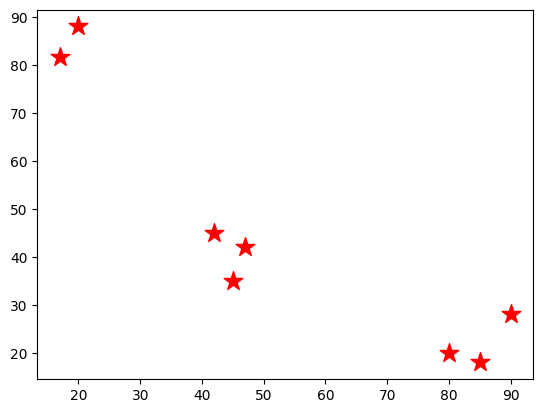

In [55]:
# Plot the centroids
plt.scatter(
    model.cluster_centers_[:, 0],  # take all x values of a centriod points(x,y) on x-axis
    model.cluster_centers_[:, 1],  # take all y values of a centriod points(x,y) on x-axis 
    marker="*",
    s=200,
    c='red'
)

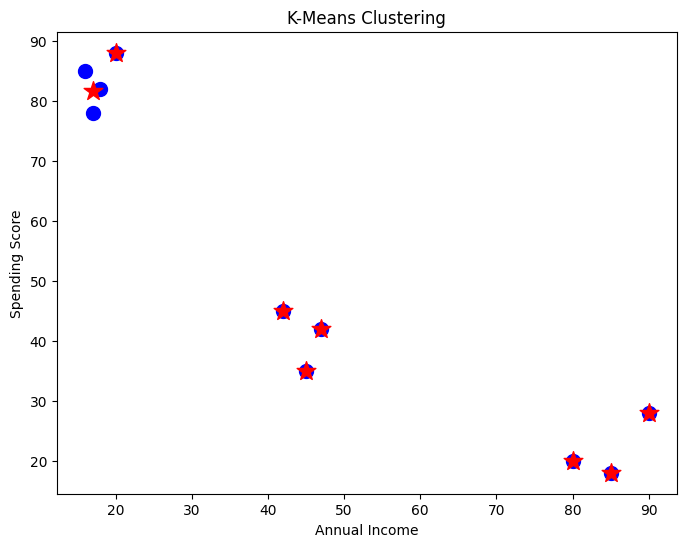

In [62]:
plt.figure(figsize=(8, 6))

# Plot training customers and color them according to their cluster
plt.scatter(
    X_train["Annual_Income"],
    X_train["Spending_Score"],
    c='blue',
    s=100
)

# Plot the centroids
plt.scatter(
    model.cluster_centers_[:, 0],  # values 
    model.cluster_centers_[:, 1],
    marker="*",
    s=200,
    c='red'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")

plt.show()

## **Make Predictions on Test Set**

In [63]:
# Assign clusters to previously unseen test customers

test_labels = model.predict(X_test)

test_labels

array([7, 6, 1, 2, 3], dtype=int32)

In [64]:
# Which cluster does belong to which to which sample
X_test_result = X_test.copy()
X_test_result['Cluster'] = test_labels
X_test_result

,Annual_Income,Spending_Score,Cluster
9,50,38,7
11,82,25,6
0,15,80,1
13,88,22,2
5,40,40,3


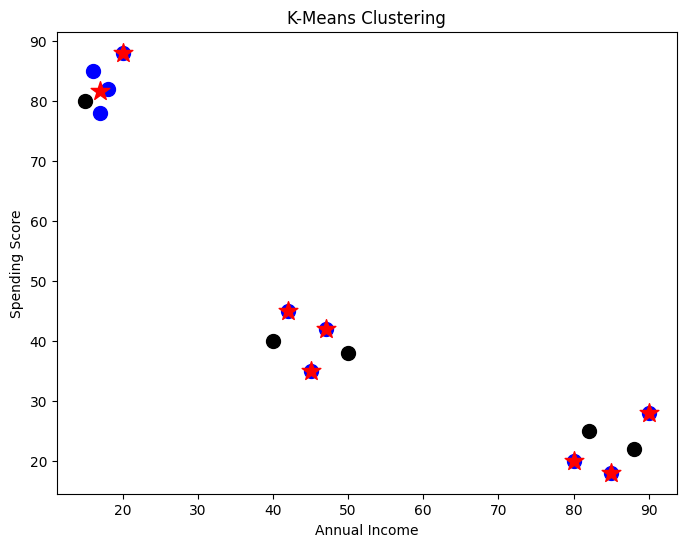

In [65]:
plt.figure(figsize=(8, 6))

# Plot training customers and color them according to their cluster
plt.scatter(
    X_train["Annual_Income"],
    X_train["Spending_Score"],
    c="blue",
    s=100
)

plt.scatter(
    X_test["Annual_Income"],
    X_test["Spending_Score"],
    c="black",
    s=100
)

# Plot the centroids
plt.scatter(
    model.cluster_centers_[:, 0],  # values 
    model.cluster_centers_[:, 1],
    marker="*",
    s=200,
    c='red'
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")

plt.show()

In [69]:
score = silhouette_score(
        X_train_scaled,
        model.labels_
    )
score

0.04030392745276813

In [70]:
model.inertia_

6.5

## **How to select n_clusters**
1) using Inertia
2) using silhouette

## Inertia
- **Inertia**: measures how close the data points are to the centroid of their cluster.

- Lower inertia = points are closer to their cluster centers.

In [71]:
inertia_values = []  # wcss within cluster sum of square

# Test different values of K
for k in range(1, 10):
    
    model = KMeans(
        n_clusters=k,
        n_init="auto",  # do best initilization of centriods not random
        random_state=42
    )
    
    model.fit(X_train_scaled)
    
    # Store the within-cluster sum of squares
    inertia_values.append(model.inertia_)

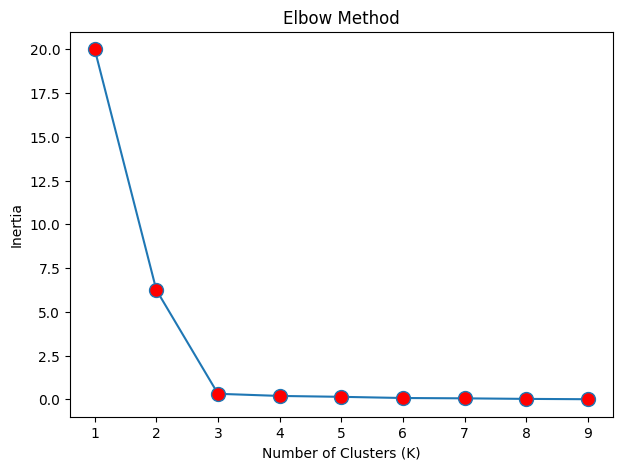

In [72]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, 10),  # on x
    inertia_values,
    marker="o",
    mfc='red',
    ms = 10
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

##  silhouette

In [77]:
silhouette_values = []

for k in range(2, 10):
    
    model = KMeans(
        n_clusters=k,
        n_init="auto",
        random_state=42
    )
    
    labels = model.fit_predict(X_train_scaled)
#   labels = model.labels_
    
    score = silhouette_score(
        X_train_scaled,
        labels
    )
    
    silhouette_values.append(score)

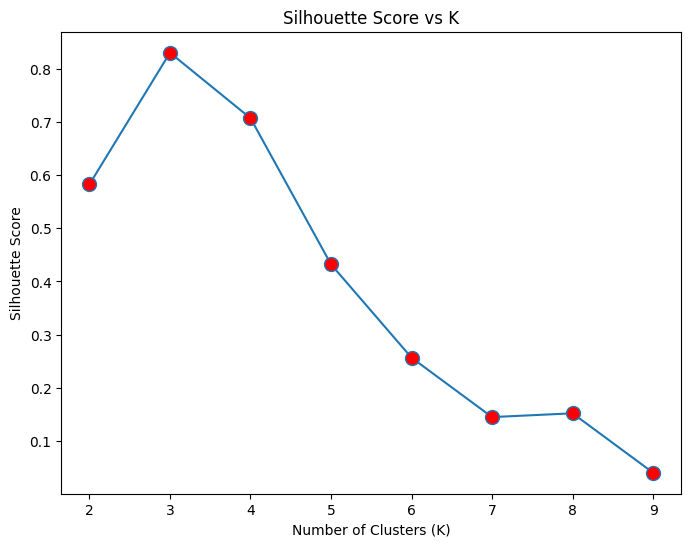

In [78]:
plt.figure(figsize=(8, 6))

plt.plot(
    range(2, 10),
    silhouette_values,
    marker="o",
    ms=10,
    mfc='r'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")

plt.show()

# Let's train the model with best parameter

In [83]:
final_model = KMeans(
    n_clusters=3,
    n_init="auto",
    random_state=42
)



In [84]:
final_model.fit(X_train)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [85]:
print("Final cluster centers:")

print(final_model.cluster_centers_)

Final cluster centers:
[[85.         22.        ]
 [17.75       83.25      ]
 [44.66666667 40.66666667]]


In [86]:
x = final_model.cluster_centers_[:, 0]
x

array([85.        , 17.75      , 44.66666667])

In [87]:
y =final_model.cluster_centers_[:, 1] 
y

array([22.        , 83.25      , 40.66666667])

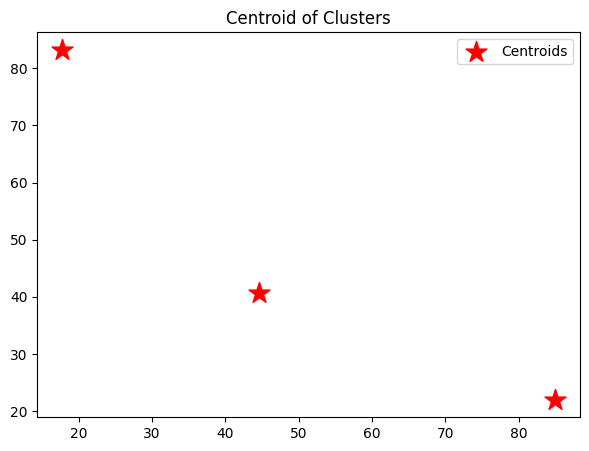

In [88]:
# Centroids
plt.figure(figsize=(7,5))
plt.scatter(
    x,
    y,
    marker="*",
    s=250,
    c='red',
    label="Centroids"
)
plt.title("Centroid of Clusters")
plt.legend()
plt.show()

### Training predictions

In [ ]:
train_predictions = final_model.predict(X_train)  # training labels

train_predictions

array([2, 1, 1, 0, 1, 2, 0, 0, 1, 2], dtype=int32)

In [94]:
final_train = X_train.copy()
final_train['cluster'] = train_predictions  # adding traning labels
final_train

,Annual_Income,Spending_Score,cluster
8,47,42,2
2,17,78,1
1,16,85,1
14,90,28,0
4,20,88,1
7,45,35,2
10,80,20,0
12,85,18,0
3,18,82,1
6,42,45,2


### Test Predictions

In [ ]:
test_predictions = final_model.predict(X_test)  # testing lables

test_predictions

array([2, 0, 1, 0, 2], dtype=int32)

In [ ]:
final_test = X_test.copy()  # deep copy

final_test["Cluster"] = test_predictions  # add cluster/label column

final_test.sort_values("Cluster")

,Annual_Income,Spending_Score,Cluster
11,82,25,0
13,88,22,0
0,15,80,1
9,50,38,2
5,40,40,2


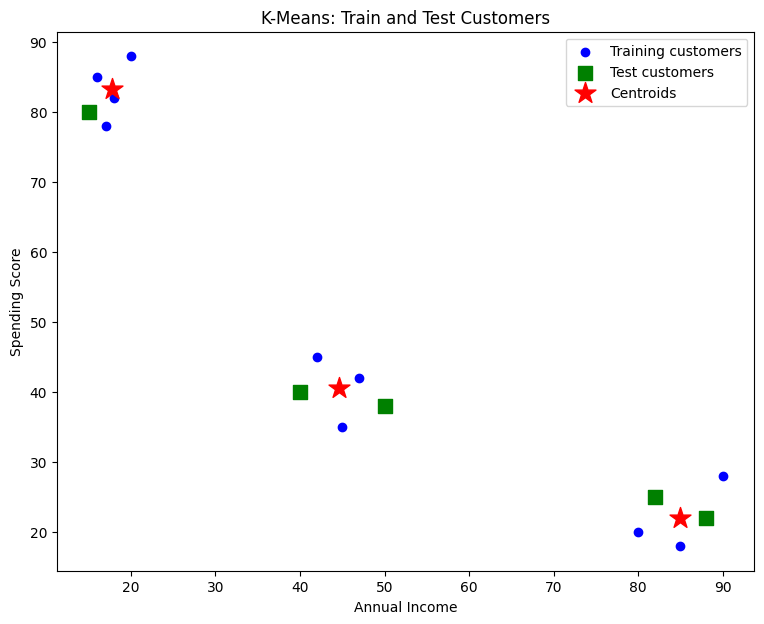

In [93]:
plt.figure(figsize=(9, 7))

# Training data
plt.scatter(
    X_train["Annual_Income"],
    X_train["Spending_Score"],
    c='blue',
    label="Training customers"
)

# Test data
plt.scatter(
    X_test["Annual_Income"],
    X_test["Spending_Score"],
    c="green",
    marker="s",  # squared
    s=100,
    label="Test customers"
)

# Centroids
plt.scatter(
    final_model.cluster_centers_[:, 0], # gives X values of the center of a cluster
    final_model.cluster_centers_[:, 1], # gives y values of the center of a cluster
    marker="*",
    s=250,
    c='red',
    label="Centroids"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means: Train and Test Customers")

plt.legend()

plt.show()

In [117]:
cluster_0 = X_train[train_labels == 0]
cluster_0

,Annual_Income,Spending_Score
7,45,35


In [118]:
cluster_1 = X_train[train_labels == 1]
cluster_1

,Annual_Income,Spending_Score
2,17,78
1,16,85
3,18,82


In [119]:
cluster_2 = X_train[train_labels == 2]
cluster_2

,Annual_Income,Spending_Score
12,85,18


In [122]:
final_model.cluster_centers_

array([[85.        , 22.        ],
       [17.75      , 83.25      ],
       [44.66666667, 40.66666667]])

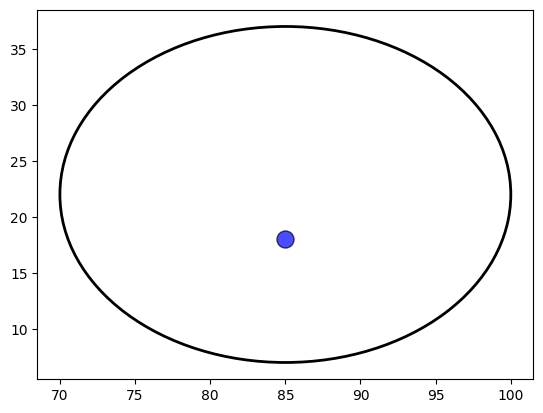

In [134]:
plt.scatter(
    cluster_2["Annual_Income"],
    cluster_2["Spending_Score"],
    c='blue',
    edgecolors='black',
    s=150,
    alpha=0.7,
    label="Cluster 2"
)

from matplotlib.patches import Circle

circle = Circle(
        (85, 22),  # (x1, y1)
        radius=15,
        fill=False,
        linestyle="solid",
        linewidth=2
    )
plt.gca().add_patch(circle)

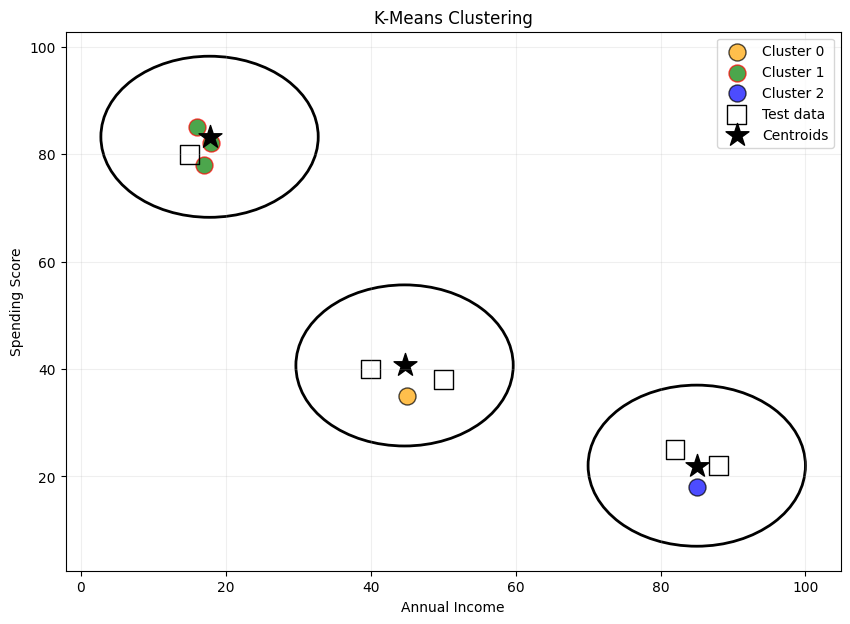

In [120]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

plt.figure(figsize=(10, 7))

# CLUSTER 0 - Training points

cluster_0 = X_train[train_labels == 0]

plt.scatter(
    cluster_0["Annual_Income"],
    cluster_0["Spending_Score"],
    c='orange',
    edgecolors='black',
    s=150,
    alpha=0.7,
    label="Cluster 0"
)


# CLUSTER 1 - Training points

cluster_1 = X_train[train_labels == 1]

plt.scatter(
    cluster_1["Annual_Income"],
    cluster_1["Spending_Score"],
    c='green',
    edgecolors='red',
    s=150,
    alpha=0.7,
    label="Cluster 1"
)


# CLUSTER 2 - Training points

cluster_2 = X_train[train_labels == 2]

plt.scatter(
    cluster_2["Annual_Income"],
    cluster_2["Spending_Score"],
    c='blue',
    edgecolors='black',
    s=150,
    alpha=0.7,
    label="Cluster 2"
)

# TEST DATA

plt.scatter(
    X_test["Annual_Income"],
    X_test["Spending_Score"],
    marker="s", # squred
    s=180,
    facecolors="none",
    edgecolor="black",
    label="Test data"
)

# CENTROIDS

plt.scatter(
    final_model.cluster_centers_[:, 0],
    final_model.cluster_centers_[:, 1],
    marker="*",
    s=300,
    c="black",
    label="Centroids"
)


# DRAW CIRCLES

for center in final_model.cluster_centers_:

    circle = Circle(
        (center[0], center[1]),
        radius=15,
        fill=False,
        linestyle="solid",
        linewidth=2
    )

    plt.gca().add_patch(circle)


plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.title("K-Means Clustering")

plt.legend()

plt.grid(alpha=0.2)

plt.show()

In [135]:
silhouette_score(X_train_scaled, final_model.labels_)

0.8298908682091467

In [136]:
silhouette_score(X_train_scaled, model.labels_)

0.04030392745276813

## Unseen point

In [104]:
point = [[20,50]]

In [105]:
point_scaled = scaler.transform(point)

c:\Users\ok\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [106]:
final_model.predict(point_scaled)

c:\Users\ok\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([2], dtype=int32)

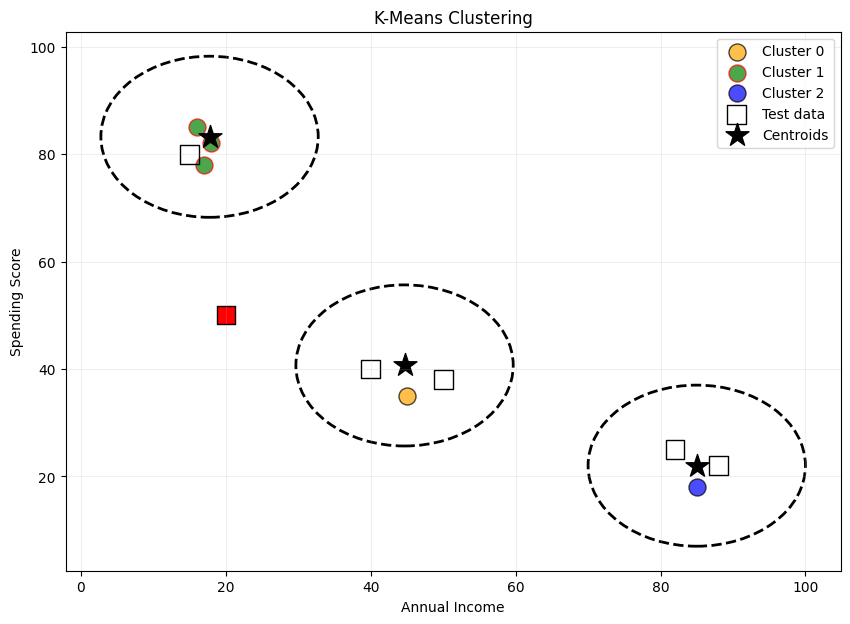

In [107]:
from matplotlib.patches import Circle

plt.figure(figsize=(10, 7))



# New points
plt.scatter(
    20,
    50,
    c='red',
    marker="s",
    s=180,
    edgecolor="black"
)



# -----------------------------------------
# CLUSTER 0 - Training points
# -----------------------------------------
cluster_0 = X_train[train_labels == 0]

plt.scatter(
    cluster_0["Annual_Income"],
    cluster_0["Spending_Score"],
    c='orange',
    edgecolors='black',
    s=150,
    alpha=0.7,
    label="Cluster 0"
)

# -----------------------------------------
# CLUSTER 1 - Training points
# -----------------------------------------
cluster_1 = X_train[train_labels == 1]

plt.scatter(
    cluster_1["Annual_Income"],
    cluster_1["Spending_Score"],
    c='green',
    edgecolors='red',
    s=150,
    alpha=0.7,
    label="Cluster 1"
)

# -----------------------------------------
# CLUSTER 2 - Training points
# -----------------------------------------
cluster_2 = X_train[train_labels == 2]

plt.scatter(
    cluster_2["Annual_Income"],
    cluster_2["Spending_Score"],
    c='blue',
    edgecolors='black',
    s=150,
    alpha=0.7,
    label="Cluster 2"
)

# -----------------------------------------
# TEST DATA
# -----------------------------------------
plt.scatter(
    X_test["Annual_Income"],
    X_test["Spending_Score"],
    marker="s", # squred
    s=180,
    facecolors="none",
    edgecolor="black",
    label="Test data"
)

# -----------------------------------------
# CENTROIDS
# -----------------------------------------
plt.scatter(
    final_model.cluster_centers_[:, 0],
    final_model.cluster_centers_[:, 1],
    marker="*",
    s=300,
    c="black",
    label="Centroids"
)

# -----------------------------------------
# DRAW CIRCLES
# -----------------------------------------
for center in final_model.cluster_centers_:

    circle = Circle(
        (center[0], center[1]),
        radius=15,
        fill=False,
        linestyle="--",
        linewidth=2
    )

    plt.gca().add_patch(circle)


plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.title("K-Means Clustering")

plt.legend()

plt.grid(alpha=0.2)

plt.show()

In [268]:
new_customer = np.array([
    [50, 45]
])

predicted_cluster = model.predict(new_customer)

print("Predicted cluster:", predicted_cluster[0])

Predicted cluster: 2


c:\Users\ok\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [269]:
import numpy as np
import pandas as pd
from sklearn.cluster import k_means
from sklearn.datasets import make_blobs

In [270]:
X, y = make_blobs(n_samples= 100, n_features= 2, centers= 4)

In [271]:
X

array([[-7.86712483e+00, -5.63902505e-01],
       [-8.47674310e+00, -8.62606684e-01],
       [-2.88700135e+00, -7.42104799e+00],
       [-4.24793917e+00, -7.38016655e+00],
       [-5.63389321e+00, -5.96307165e+00],
       [-3.75447673e+00, -7.59845889e+00],
       [ 5.98355762e-01, -8.05972624e+00],
       [-4.06124080e+00, -7.84543717e+00],
       [ 1.15735346e+00, -7.77828501e+00],
       [-5.24691049e+00, -6.85176254e+00],
       [-6.50811462e+00, -1.58467027e-01],
       [ 7.05884361e+00, -7.88056490e+00],
       [-8.48346984e+00, -4.04596405e-01],
       [ 2.38859159e+00, -8.10103918e+00],
       [-3.80681222e+00, -7.82587258e+00],
       [ 4.64647320e+00, -9.30960533e+00],
       [ 4.65334228e+00, -8.52167466e+00],
       [-5.64186650e+00,  1.08681433e-02],
       [-7.64207813e+00, -1.09777404e+00],
       [ 1.81392548e+00, -9.37694898e+00],
       [ 1.45698329e+00, -9.55857146e+00],
       [ 4.85503806e+00, -9.86679859e+00],
       [-4.93186199e+00, -7.91071019e+00],
       [ 4.

In [272]:
X[:, 0]

array([-7.86712483, -8.4767431 , -2.88700135, -4.24793917, -5.63389321,
       -3.75447673,  0.59835576, -4.0612408 ,  1.15735346, -5.24691049,
       -6.50811462,  7.05884361, -8.48346984,  2.38859159, -3.80681222,
        4.6464732 ,  4.65334228, -5.6418665 , -7.64207813,  1.81392548,
        1.45698329,  4.85503806, -4.93186199,  4.49271606,  6.41787892,
        1.95523623, -4.31176256,  3.07144129,  1.12169193,  7.69254481,
       -7.30220738,  5.24299935,  1.01626032,  0.1004262 ,  5.4671958 ,
       -6.45993746, -0.87319289,  1.56710535,  5.26047419,  0.63411713,
       -5.8368055 , -3.22344405,  1.3409575 , -5.4073807 ,  0.88297675,
        6.17335737, -5.6627799 , -7.41097688, -5.50918748,  5.98226504,
        2.77501171,  5.78813326, -3.40390994,  8.1058304 , -6.03939411,
       -6.50114761,  0.45340504, -3.83774956,  0.9209482 ,  6.50735911,
        6.82074214, -7.46524994, -7.81708344, -4.5507285 ,  7.24530141,
       -4.48507425, -5.12125546,  2.8556456 , -7.77201691,  1.15

In [273]:
X[: , 1]

array([-5.63902505e-01, -8.62606684e-01, -7.42104799e+00, -7.38016655e+00,
       -5.96307165e+00, -7.59845889e+00, -8.05972624e+00, -7.84543717e+00,
       -7.77828501e+00, -6.85176254e+00, -1.58467027e-01, -7.88056490e+00,
       -4.04596405e-01, -8.10103918e+00, -7.82587258e+00, -9.30960533e+00,
       -8.52167466e+00,  1.08681433e-02, -1.09777404e+00, -9.37694898e+00,
       -9.55857146e+00, -9.86679859e+00, -7.91071019e+00, -8.92502661e+00,
       -9.53351246e+00, -9.60595794e+00, -7.44360660e+00, -1.10184269e+01,
       -9.05590870e+00, -8.25007873e+00, -2.35126994e-01, -8.28717222e+00,
       -9.43976509e+00, -1.06981355e+01, -7.67257023e+00, -1.94809510e+00,
       -6.47829623e+00, -9.77948751e+00, -8.52850634e+00, -9.73019043e+00,
       -8.08225584e+00, -6.09565811e+00, -1.01504999e+01, -6.64147747e+00,
       -9.95502843e+00, -8.29132739e+00, -1.53781721e+00, -1.88322787e-01,
       -7.61454739e+00, -8.23875012e+00, -9.51060482e+00, -8.69599080e+00,
       -7.38242183e+00, -

In [274]:
import matplotlib.pyplot as plt

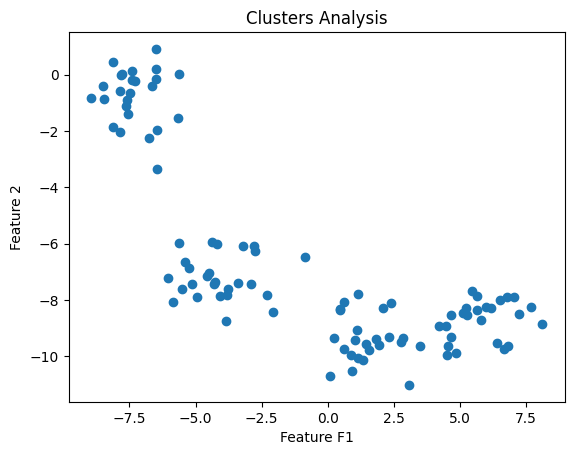

In [275]:
plt.title("Clusters Analysis")
plt.scatter(X[:, 0], X[: , 1])
plt.xlabel("Feature F1")
plt.ylabel("Feature 2")
plt.show()

In [276]:
cluster = k_means()

TypeError: missing a required argument: 'X'

In [ ]:
cluster = k_means(n_clusters=3, n_init='auto',)
